In [6]:
import numpy as np
import tensorflow as tf

In [7]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)
X = housing.data.values.astype(np.float32)
y= housing.target.values.astype(np.float32)
print(f"Features: {housing.feature_names}")
print(f"Shape: X = {X.shape} | y = {y.shape}")
print(f"Target range: {y.min():.2f} - {y.max():.2f} ($100k)")

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Shape: X = (20640, 8) | y = (20640,)
Target range: 0.15 - 5.00 ($100k)


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)
print(f"\nTrain: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")


Train: 8772 | Val: 8772 | Test: 3096


In [9]:
from tensorflow import keras
def build_house_model(input_dim):
    inputs = keras.Input(shape = (input_dim,), name = 'features')

    x = keras.layers.Dense(256)(inputs)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.2)(x)

    x = keras.layers.Dense(128)(inputs)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.2)(x)


    x = keras.layers.Dense(64)(inputs)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.2)(x)

    outputs = keras.layers.Dense(1, name='price_output')(x)
    return keras.Model(inputs, outputs, name = 'HousePriceANN')

In [15]:
model = build_house_model(input_dim=8)
model.summary()

Model: "HousePriceANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ features (InputLayer)                │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 64)                  │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_8 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ price_output (Dense)                 │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 128 (512.00 B)

<h5>Compile</h5>

In [17]:
#compilation before trainx
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss = 'mse',
    metrics = ['mae']
    
)

<h5>Callbacks</h5>

In [28]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor = 'val_los', patience=15,
        restore_best_weights=True, verbose = 1, mode='min'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor = 'val_loss', factor = 0.5, patience=7,
        min_lr=1e-6, verbose = 1
    ),
    keras.callbacks.ModelCheckpoint(
        'best_house_model.keras', monitor='val_loss',
        save_best_only=True, verbose=0
    )
]

<h5>Train</h5>

In [29]:
history = model.fit(
    X_train, y_train,
    epochs=200, batch_size=256,
    validation_data=(X_val, y_val),
    callbacks=callbacks, verbose=1
)

Epoch 1/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1.1556 - mae: 0.7764 - val_loss: 1.0338 - val_mae: 0.7273 - learning_rate: 0.0010
Epoch 2/200
 1/35 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.9385 - mae: 0.7345

C:\Anaconda\Lib\site-packages\keras\src\callbacks\early_stopping.py:100: UserWarning: Early stopping conditioned on metric `val_los` which is not available. Available metrics are: loss,mae,val_loss,val_mae
  current = self.get_monitor_value(logs)


35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 1.0803 - mae: 0.7490 - val_loss: 0.8978 - val_mae: 0.6726 - learning_rate: 0.0010
Epoch 3/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.9882 - mae: 0.7233 - val_loss: 0.7782 - val_mae: 0.6210 - learning_rate: 0.0010
Epoch 4/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.9507 - mae: 0.7092 - val_loss: 0.7328 - val_mae: 0.6036 - learning_rate: 0.0010
Epoch 5/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.9032 - mae: 0.6982 - val_loss: 0.6886 - val_mae: 0.5822 - learning_rate: 0.0010
Epoch 6/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.9172 - mae: 0.6891 - val_loss: 0.6490 - val_mae: 0.5635 - learning_rate: 0.0010
Epoch 7/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.8365 - mae: 0.6664 - val_loss: 0.6025 - val_mae: 0.5424 - learning_rate: 0.0010
Epoch 8/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.8179 - mae: 0.6576 - val_loss: 0.5891 - val_mae: 0.5342 - learning_rate: 0.0010
Epoch 9/200
35/35 

<h5>Evaluate</h5>

In [30]:
from sklearn.metrics import r2_score
results = model.evaluate(X_test, y_test, verbose=0)
print(f"\n=== TEST RESULTS ===")
print(f"MSE: {results[0]:.4f}")
print(f"MAE: {results[1]:.4f} (${results[1]*100:.0f}k avaerage error)")
y_pred = model.predict(X_test, verbose=0).flatten()
r2 = r2_score(y_test, y_pred)
print(f"R^2: {r2:.4f} (1.0 = perfect)")


=== TEST RESULTS ===
MSE: 0.4898
MAE: 0.4815 ($48k avaerage error)
R^2: 0.6262 (1.0 = perfect)


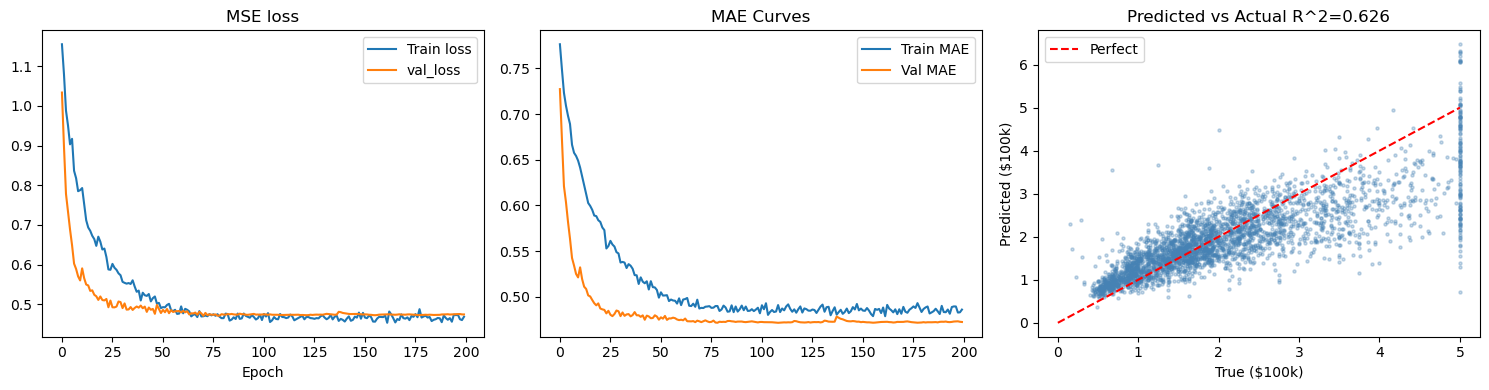

In [33]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15,4))
axes[0].plot(history.history['loss'], label='Train loss')
axes[0].plot(history.history['val_loss'], label='val_loss')
axes[0].set_title('MSE loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('MAE Curves')
axes[1].legend()
axes[2].scatter(y_test, y_pred, alpha=0.3, s=5, color='steelblue')
axes[2].plot([0,5], [0,5], 'r--', label='Perfect')
axes[2].set_xlabel('True ($100k)')
axes[2].set_ylabel('Predicted ($100k)')
axes[2].set_title(f"Predicted vs Actual R^2={r2:.3f}")
axes[2].legend()
plt.tight_layout()
plt.savefig('house_price-results.png', dpi=150)
plt.show()